In [18]:
# ==============================================================================
# Physics-Informed Neural Network (PINN) for the Black–Scholes PDE
# European Call & Put Option Pricing with Automatic Differentiation & Greeks
# ==============================================================================

# --- Cell 1: Imports and Device Setup ---
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Hardware Detection (CPU, CUDA GPU, or Apple MPS)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using compute device: {device}")

Using compute device: cuda


In [19]:
# --- Cell 2: Financial Model Parameters & Analytical Black-Scholes Formulas ---
# Primary Parameters
S0 = 100.0      # Current Asset Price
K = 100.0       # Strike Price
T = 1.0         # Time-to-maturity (years)
r = 0.05        # Risk-free interest rate
sigma = 0.2     # Volatility

# PINN Domain Boundaries
S_min = 1.0e-2  # Lower bound for S (avoid zero division)
S_max = 300.0   # Upper bound for S (~3x Strike)

def bs_analytical(S, K, tau, r, sigma, option_type="call"):
    """
    Classical Black-Scholes formula.
    tau: Time-to-maturity (tau = T - t)
    Returns: Option Price, Delta, Gamma, Vega, Theta
    """
    S = np.maximum(np.array(S, dtype=np.float64), 1e-8)
    tau = np.maximum(np.array(tau, dtype=np.float64), 1e-8)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    pdf_d1 = norm.pdf(d1)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
        delta = norm.cdf(d1)
        theta = - (S * pdf_d1 * sigma) / (2 * np.sqrt(tau)) - r * K * np.exp(-r * tau) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1.0
        theta = - (S * pdf_d1 * sigma) / (2 * np.sqrt(tau)) + r * K * np.exp(-r * tau) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    gamma = pdf_d1 / (S * sigma * np.sqrt(tau))
    vega = S * pdf_d1 * np.sqrt(tau)

    return price, delta, gamma, vega, theta

print("Analytical BS Function Defined.")

Analytical BS Function Defined.


In [20]:
# --- Cell 3: Neural Network Architecture with Domain Normalization ---
class BlackScholesPINN(nn.Module):
    """
    Deep Neural Network for Black-Scholes PDE.
    Inputs: Raw (S, tau)
    Internal Normalization: S scaled by K (dimensionless price x = S/K), tau kept in [0, T]
    """
    def __init__(self, K, hidden_dim=64, num_layers=4):
        super(BlackScholesPINN, self).__init__()
        self.K = K

        layers = [nn.Linear(2, hidden_dim), nn.SiLU()] # SiLU/Swish ensures smooth second derivatives
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers) # * unpacking the list from the layers and nn.Sequential making forward flow
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight) # xavier_normsl_ just takes random values in carefully corrected way
                nn.init.zeros_(m.bias)

    def forward(self, S, tau):
        # Scale inputs to normalized space for training stability
        x = S / self.K
        t_scaled = tau / T
        inputs = torch.cat([x, t_scaled], dim=1)
        return self.net(inputs)

print("PINN Architecture Defined.")

PINN Architecture Defined.


In [21]:
# --- Cell 4: Training Setup (Collocation Points & Loss Computation) ---
def generate_training_data(N_pde=4000, N_ic=1000, N_bc=1000):
    """Generates Latin-Hypercube style random points across domain."""
    # Interior Collocation Points
    S_pde = torch.rand(N_pde, 1) * (S_max - S_min) + S_min
    tau_pde = torch.rand(N_pde, 1) * T

    # Initial Condition Points (tau = 0)
    S_ic = torch.rand(N_ic, 1) * (S_max - S_min) + S_min
    tau_ic = torch.zeros(N_ic, 1)

    # Boundary Condition Points (S = S_min and S = S_max)
    tau_bc = torch.rand(N_bc, 1) * T
    S_bc_min = torch.full((N_bc // 2, 1), S_min)
    S_bc_max = torch.full((N_bc // 2, 1), S_max)

    tau_bc_split = torch.chunk(tau_bc, 2, dim=0)

    return (S_pde.to(device), tau_pde.to(device),
            S_ic.to(device), tau_ic.to(device),
            S_bc_min.to(device), S_bc_max.to(device),
            tau_bc_split[0].to(device), tau_bc_split[1].to(device))

def compute_pinn_loss(model, data, r, sigma, K, option_type="call"):
    S_pde, tau_pde, S_ic, tau_ic, S_bc_min, S_bc_max, tau_bc1, tau_bc2 = data

    # 1. PDE Loss in Domain Interior
    S_pde.requires_grad_(True)
    tau_pde.requires_grad_(True)

    V = model(S_pde, tau_pde)

    # First derivatives
    dV_dS = torch.autograd.grad(V, S_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    dV_dtau = torch.autograd.grad(V, tau_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]

    # Second derivative w.r.t S
    d2V_dS2 = torch.autograd.grad(dV_dS, S_pde, grad_outputs=torch.ones_like(dV_dS), create_graph=True)[0]

    # Black-Scholes PDE Residual under tau = T - t transformation:
    # dV/dtau - 0.5 * sigma^2 * S^2 * d2V/dS2 - r * S * dV/dS + r * V = 0
    pde_residual = dV_dtau - 0.5 * (sigma**2) * (S_pde**2) * d2V_dS2 - r * S_pde * dV_dS + r * V
    loss_pde = torch.mean(pde_residual**2)

    # 2. Initial Condition Loss (tau = 0, Payoff)
    V_ic_pred = model(S_ic, tau_ic)
    if option_type == "call":
        V_ic_exact = torch.relu(S_ic - K)
    else:
        V_ic_exact = torch.relu(K - S_ic)
    loss_ic = torch.mean((V_ic_pred - V_ic_exact)**2)

    # 3. Boundary Condition Losses
    # As S -> S_min
    V_bc_min_pred = model(S_bc_min, tau_bc1)
    if option_type == "call":
        V_bc_min_exact = torch.zeros_like(S_bc_min)
    else:
        V_bc_min_exact = K * torch.exp(-r * tau_bc1) - S_bc_min

    # As S -> S_max
    V_bc_max_pred = model(S_bc_max, tau_bc2)
    if option_type == "call":
        V_bc_max_exact = S_bc_max - K * torch.exp(-r * tau_bc2)
    else:
        V_bc_max_exact = torch.zeros_like(S_bc_max)

    loss_bc = torch.mean((V_bc_min_pred - V_bc_min_exact)**2) + torch.mean((V_bc_max_pred - V_bc_max_exact)**2)

    # Combined Loss with weighting
    total_loss = 0.5 * loss_pde + 5.0 * loss_ic + 5.0 * loss_bc
    return total_loss, loss_pde, loss_ic, loss_bc

print("Loss Calculation Routines Defined.")

Loss Calculation Routines Defined.


In [22]:
# --- Cell 5: Training Loop ---
def train_pinn(option_type, epochs, lr):
    print(f"\n--- Starting PINN Training for European {option_type.upper()} Option ---")
    model = BlackScholesPINN(K=K).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=500)

    data = generate_training_data()
    loss_history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss, l_pde, l_ic, l_bc = compute_pinn_loss(model, data, r, sigma, K, option_type=option_type)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        loss_history.append(loss.item())

        if epoch % 1000 == 0 or epoch == 1:
            print(f"Epoch {epoch:5d}/{epochs} | Total Loss: {loss.item():.6e} | "
                  f"PDE: {l_pde.item():.6e} | IC: {l_ic.item():.6e} | BC: {l_bc.item():.6e}")

    return model, loss_history

# Train Call Option Model
model_call, history_call = train_pinn(option_type="call", epochs=100000, lr=2e-3)

# Train Put Option Model
model_put, history_put = train_pinn(option_type="put", epochs=100000, lr=2e-3)


--- Starting PINN Training for European CALL Option ---
Epoch     1/100000 | Total Loss: 2.517797e+05 | PDE: 1.359345e-05 | IC: 9.345344e+03 | BC: 4.101059e+04
Epoch  1000/100000 | Total Loss: 4.617011e+00 | PDE: 2.689700e+00 | IC: 6.362935e-01 | BC: 1.813868e-02
Epoch  2000/100000 | Total Loss: 2.819170e+00 | PDE: 3.138292e+00 | IC: 2.382372e-01 | BC: 1.176752e-02
Epoch  3000/100000 | Total Loss: 2.290026e+00 | PDE: 2.810040e+00 | IC: 1.667393e-01 | BC: 1.026200e-02
Epoch  4000/100000 | Total Loss: 1.869448e+00 | PDE: 2.293095e+00 | IC: 1.357723e-01 | BC: 8.807824e-03
Epoch  5000/100000 | Total Loss: 1.468699e+00 | PDE: 1.730843e+00 | IC: 1.141854e-01 | BC: 6.470056e-03
Epoch  6000/100000 | Total Loss: 1.155744e+00 | PDE: 1.314296e+00 | IC: 9.790405e-02 | BC: 1.815161e-03
Epoch  7000/100000 | Total Loss: 1.006545e+00 | PDE: 1.146503e+00 | IC: 8.535684e-02 | BC: 1.301911e-03
Epoch  8000/100000 | Total Loss: 4.367944e+01 | PDE: 1.006801e+00 | IC: 2.150703e+00 | BC: 6.484506e+00
Epoch  

In [23]:
# --- Cell 6: Evaluation & AutoDiff Greeks Extraction ---
def evaluate_pinn_and_greeks(model, S_vec, tau_val, option_type="call"):
    model.eval()

    S_tensor = torch.tensor(S_vec, dtype=torch.float32, device=device).unsqueeze(1).requires_grad_(True)
    tau_tensor = torch.full_like(S_tensor, tau_val, dtype=torch.float32, device=device).requires_grad_(True)

    V_pred = model(S_tensor, tau_tensor)

    # First derivatives via AutoDiff
    dV_dS = torch.autograd.grad(V_pred, S_tensor, grad_outputs=torch.ones_like(V_pred), create_graph=True)[0]
    dV_dtau = torch.autograd.grad(V_pred, tau_tensor, grad_outputs=torch.ones_like(V_pred), create_graph=True)[0]

    # Second derivative
    d2V_dS2 = torch.autograd.grad(dV_dS, S_tensor, grad_outputs=torch.ones_like(dV_dS))[0]

    # Map derivatives to Greeks:
    # Delta = dV/dS
    # Gamma = d2V/dS2
    # Theta = dV/dt = - dV/dtau  (since tau = T - t)
    pinn_price = V_pred.detach().cpu().numpy().flatten()
    pinn_delta = dV_dS.detach().cpu().numpy().flatten()
    pinn_gamma = d2V_dS2.detach().cpu().numpy().flatten()
    pinn_theta = -dV_dtau.detach().cpu().numpy().flatten()

    return pinn_price, pinn_delta, pinn_gamma, pinn_theta

# Validation Domain
S_eval = np.linspace(20.0, 200.0, 200)
tau_eval = 1.0 # At t=0 (full time to maturity tau=1.0)

# 1. European Call Evaluation
bs_price_c, bs_delta_c, bs_gamma_c, _, bs_theta_c = bs_analytical(S_eval, K, tau_eval, r, sigma, "call")
pinn_price_c, pinn_delta_c, pinn_gamma_c, pinn_theta_c = evaluate_pinn_and_greeks(model_call, S_eval, tau_eval, "call")

# Metrics
mae_c = np.mean(np.abs(pinn_price_c - bs_price_c))
rmse_c = np.sqrt(np.mean((pinn_price_c - bs_price_c)**2))
max_err_c = np.max(np.abs(pinn_price_c - bs_price_c))

print(f"\n================ European Call Validation Metrics ================")
print(f"MAE: {mae_c:.4f} | RMSE: {rmse_c:.4f} | Max Abs Error: {max_err_c:.4f}")

# 2. European Put Evaluation
bs_price_p, bs_delta_p, bs_gamma_p, _, bs_theta_p = bs_analytical(S_eval, K, tau_eval, r, sigma, "put")
pinn_price_p, pinn_delta_p, pinn_gamma_p, pinn_theta_p = evaluate_pinn_and_greeks(model_put, S_eval, tau_eval, "put")

mae_p = np.mean(np.abs(pinn_price_p - bs_price_p))
rmse_p = np.sqrt(np.mean((pinn_price_p - bs_price_p)**2))
max_err_p = np.max(np.abs(pinn_price_p - bs_price_p))

print(f"\n================ European Put Validation Metrics =================")
print(f"MAE: {mae_p:.4f} | RMSE: {rmse_p:.4f} | Max Abs Error: {max_err_p:.4f}")


================ European Call Validation Metrics ================
MAE: 0.0097 | RMSE: 0.0157 | Max Abs Error: 0.0376

================ European Put Validation Metrics =================
MAE: 0.0301 | RMSE: 0.0485 | Max Abs Error: 0.1125


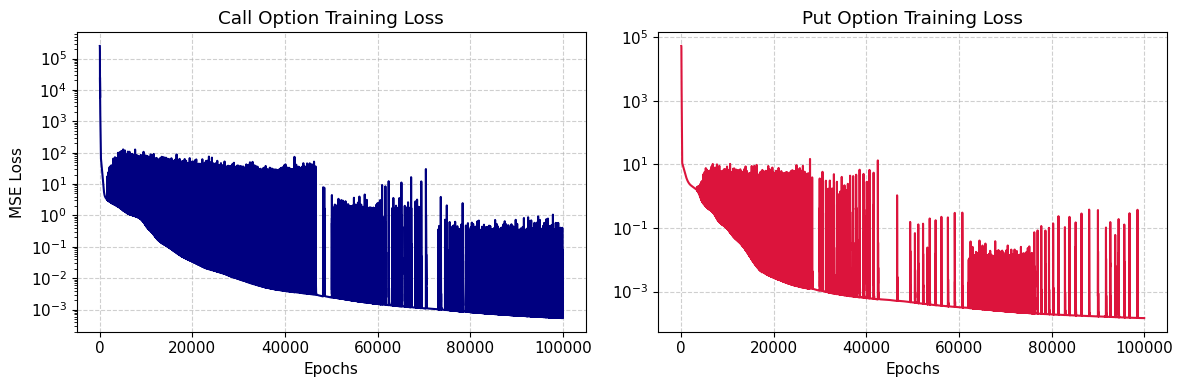

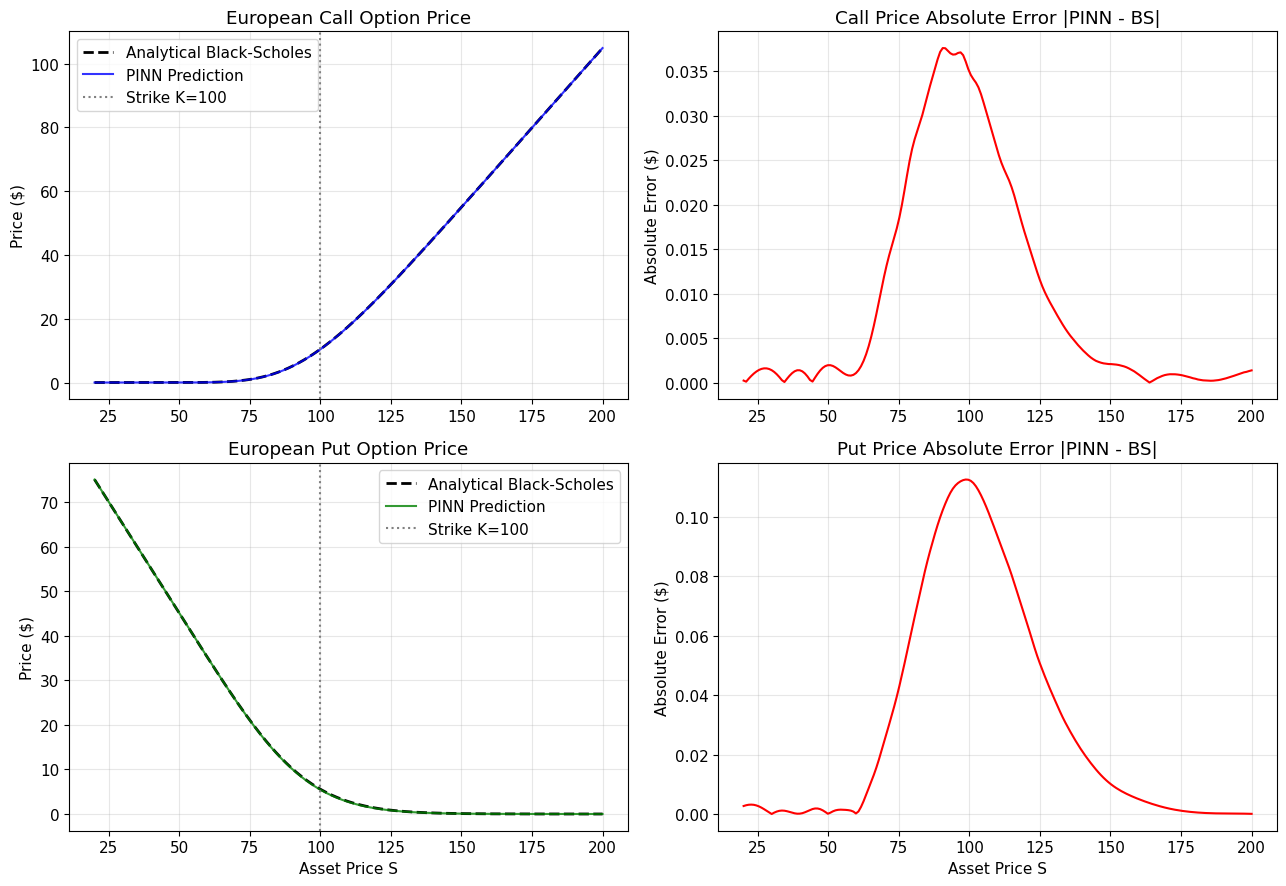

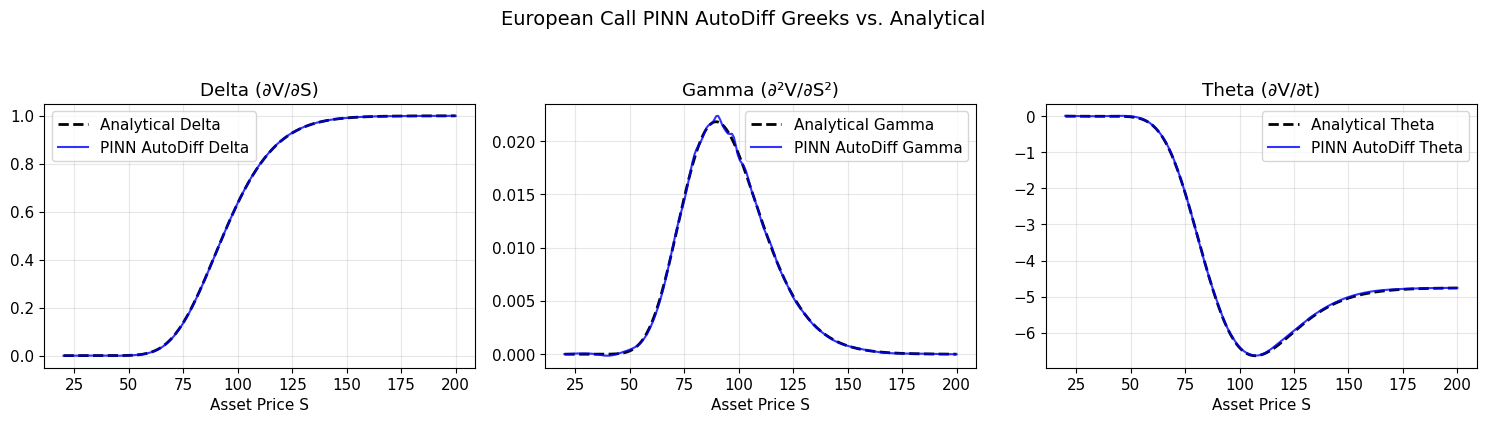

In [24]:
# --- Cell 7: Visualizations & Analysis ---
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

# 1. Training Loss Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(history_call, color='navy', label='Call PINN Loss')
ax[0].set_title("Call Option Training Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("MSE Loss")
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].semilogy(history_put, color='crimson', label='Put PINN Loss')
ax[1].set_title("Put Option Training Loss")
ax[1].set_xlabel("Epochs")
ax[1].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Option Price Comparisons & Absolute Errors
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# Call Prices
ax[0, 0].plot(S_eval, bs_price_c, 'k--', label='Analytical Black-Scholes', linewidth=2)
ax[0, 0].plot(S_eval, pinn_price_c, 'b-', label='PINN Prediction', alpha=0.8)
ax[0, 0].axvline(K, color='gray', linestyle=':', label='Strike K=100')
ax[0, 0].set_title("European Call Option Price")
ax[0, 0].set_ylabel("Price ($)")
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.3)

# Call Error
ax[0, 1].plot(S_eval, np.abs(pinn_price_c - bs_price_c), 'r-')
ax[0, 1].set_title("Call Price Absolute Error |PINN - BS|")
ax[0, 1].set_ylabel("Absolute Error ($)")
ax[0, 1].grid(True, alpha=0.3)

# Put Prices
ax[1, 0].plot(S_eval, bs_price_p, 'k--', label='Analytical Black-Scholes', linewidth=2)
ax[1, 0].plot(S_eval, pinn_price_p, 'g-', label='PINN Prediction', alpha=0.8)
ax[1, 0].axvline(K, color='gray', linestyle=':', label='Strike K=100')
ax[1, 0].set_title("European Put Option Price")
ax[1, 0].set_xlabel("Asset Price S")
ax[1, 0].set_ylabel("Price ($)")
ax[1, 0].legend()
ax[1, 0].grid(True, alpha=0.3)

# Put Error
ax[1, 1].plot(S_eval, np.abs(pinn_price_p - bs_price_p), 'r-')
ax[1, 1].set_title("Put Price Absolute Error |PINN - BS|")
ax[1, 1].set_xlabel("Asset Price S")
ax[1, 1].set_ylabel("Absolute Error ($)")
ax[1, 1].grid(True, alpha=0.3)

plt.show()

# 3. European Call Greeks (Delta, Gamma, Theta) Comparison
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Delta
ax[0].plot(S_eval, bs_delta_c, 'k--', label='Analytical Delta', linewidth=2)
ax[0].plot(S_eval, pinn_delta_c, 'b-', label='PINN AutoDiff Delta', alpha=0.8)
ax[0].set_title("Delta (∂V/∂S)")
ax[0].set_xlabel("Asset Price S")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gamma
ax[1].plot(S_eval, bs_gamma_c, 'k--', label='Analytical Gamma', linewidth=2)
ax[1].plot(S_eval, pinn_gamma_c, 'b-', label='PINN AutoDiff Gamma', alpha=0.8)
ax[1].set_title("Gamma (∂²V/∂S²)")
ax[1].set_xlabel("Asset Price S")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Theta
ax[2].plot(S_eval, bs_theta_c, 'k--', label='Analytical Theta', linewidth=2)
ax[2].plot(S_eval, pinn_theta_c, 'b-', label='PINN AutoDiff Theta', alpha=0.8)
ax[2].set_title("Theta (∂V/∂t)")
ax[2].set_xlabel("Asset Price S")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.suptitle("European Call PINN AutoDiff Greeks vs. Analytical", y=1.05, fontsize=14)
plt.show()

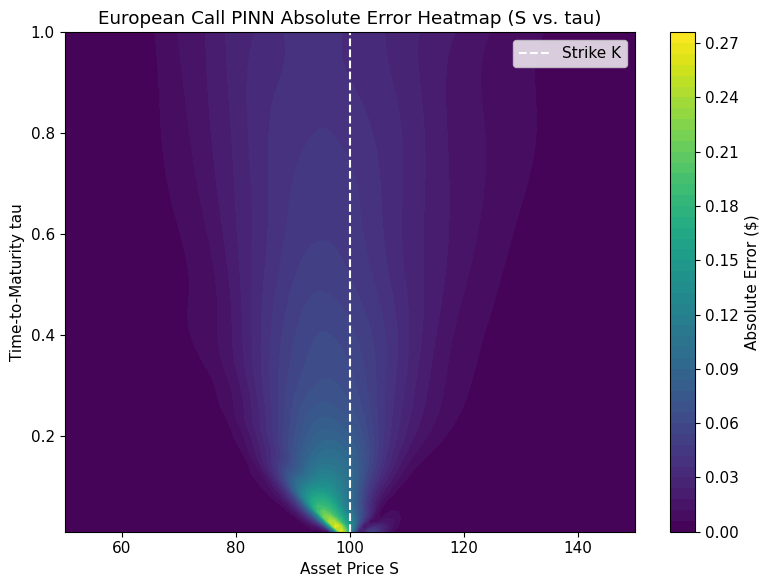

In [26]:
# --- Cell 8: 2D Space-Time Error Heatmap ---
# Grid over S x tau
S_grid = np.linspace(50.0, 150.0, 100)
tau_grid = np.linspace(0.01, 1.0, 100)
S_mesh, tau_mesh = np.meshgrid(S_grid, tau_grid)

# Compute Analytical & PINN Solutions across Mesh
bs_mesh_c, _, _, _, _ = bs_analytical(S_mesh, K, tau_mesh, r, sigma, "call")

model_call.eval()
S_flat = torch.tensor(S_mesh.flatten(), dtype=torch.float32, device=device).unsqueeze(1)
tau_flat = torch.tensor(tau_mesh.flatten(), dtype=torch.float32, device=device).unsqueeze(1)

with torch.no_grad():
    pinn_mesh_c = model_call(S_flat, tau_flat).cpu().numpy().reshape(S_mesh.shape)

abs_err_mesh = np.abs(pinn_mesh_c - bs_mesh_c)

plt.figure(figsize=(8, 6))
contour = plt.contourf(S_mesh, tau_mesh, abs_err_mesh, levels=50, cmap='viridis')
plt.colorbar(contour, label='Absolute Error ($)')
plt.title("European Call PINN Absolute Error Heatmap (S vs. tau)")
plt.xlabel("Asset Price S")
plt.ylabel("Time-to-Maturity tau")
plt.axvline(K, color='white', linestyle='--', label='Strike K')
plt.legend()
plt.show()